In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
colors = ["salmon", "lime", "skyblue"]

Load the dataset

In [27]:
# Load the provided training and testing data
train = np.loadtxt("trian.txt", delimiter=",")
dev = np.loadtxt("dev.txt", delimiter=",")
X_train = train[:, :2]
y_train = train[:, 2].astype(int) - 1
X_test = dev[:, :2]
y_test = dev[:, 2].astype(int) - 1

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("\nTraining class distribution:")
for k in range(3):
    print("Class", k + 1, ":", np.sum(y_train == k))
print("\nTesting class distribution:")
for k in range(3):
    print("Class", k + 1, ":", np.sum(y_test == k))

Training data shape: (1050, 2)
Testing data shape: (300, 2)

Training class distribution:
Class 1 : 350
Class 2 : 350
Class 3 : 350

Testing class distribution:
Class 1 : 100
Class 2 : 100
Class 3 : 100


Estimate the parameters using MLE

In [28]:
mu_est = []
prior_est = []
sigma_est = []
for k in range(3):
    Xk = X_train[y_train == k]
    mu_k = Xk.mean(axis=0)
    R = Xk - mu_k
    S = R.T @ R / len(R)                 
    mu_est.append(mu_k)
    prior_est.append(len(Xk) / len(X_train))
    sigma_est.append(S)

print("estimated priors:", np.round(prior_est, 3))
for k in range(3):
    print("class", k+1, "mean:", np.round(mu_est[k], 2))
    print("class", k+1, "covariance:\n", np.round(sigma_est[k], 1))
    print("class", k+1, "correlation:", np.round(sigma_est[k][0, 1] / np.sqrt(sigma_est[k][0, 0] * sigma_est[k][1, 1]), 3))

estimated priors: [0.333 0.333 0.333]
class 1 mean: [ 583.79 1441.97]
class 1 covariance:
 [[25117.8  4183.8]
 [ 4183.8 59211.7]]
class 1 correlation: 0.108
class 2 mean: [ 339.33 2036.19]
class 2 covariance:
 [[ 6391.2 -5902.4]
 [-5902.4 42093.3]]
class 2 correlation: -0.36
class 3 mean: [ 476.91 1037.76]
class 3 covariance:
 [[20943.3 25289.7]
 [25289.7 82273.9]]
class 3 correlation: 0.609


Classify the test data

In [29]:
scores = np.zeros((len(X_test), 3))
for k in range(3):
    diff = X_test - mu_est[k]
    scores[:, k] = -0.5*np.sum(diff @ np.linalg.inv(sigma_est[k]) * diff, axis=1) - 0.5*np.log(np.linalg.det(sigma_est[k])) + np.log(prior_est[k])
y_pred = np.argmax(scores, axis=1)

# softmax: scores -> posterior probabilities (subtract the row maximum for numerical safety)
shifted = scores - np.max(scores, axis=1, keepdims=True)
probabilities = np.exp(shifted) / np.sum(np.exp(shifted), axis=1, keepdims=True)

Confusion matrix and accuracy

In [30]:
confusion_matrix = np.zeros((3, 3), dtype=int)
for t, p in zip(y_test, y_pred):
    confusion_matrix[t, p] += 1

accuracy = np.trace(confusion_matrix) / confusion_matrix.sum()
print("accuracy: %.2f%%" % (accuracy * 100))
display(pd.DataFrame(confusion_matrix, index=["true 1", "true 2", "true 3"], columns=["predicted 1", "predicted 2", "predicted 3"]))

accuracy: 89.00%


,predicted 1,predicted 2,predicted 3
true 1,85,4,11
true 2,6,93,1
true 3,11,0,89


Plot the decision boundary

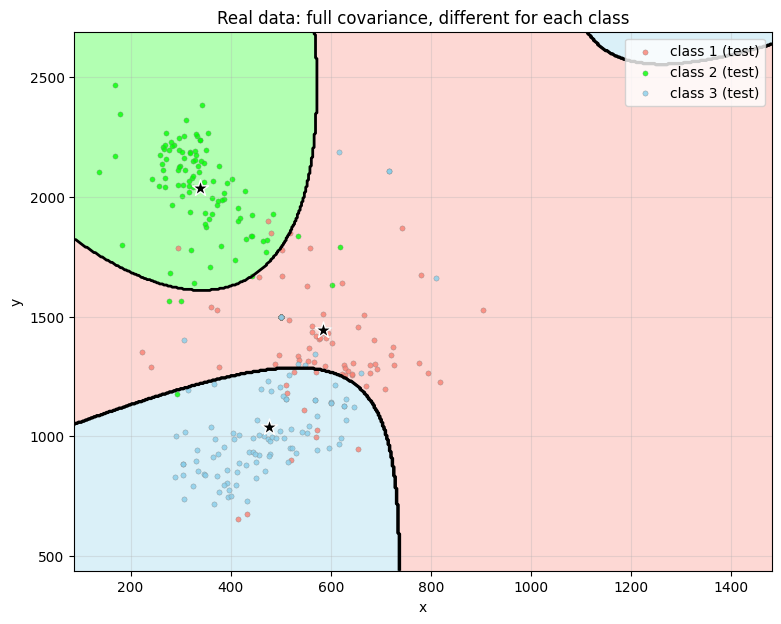

In [31]:
all_x = np.vstack((X_train, X_test))
xx, yy = np.meshgrid(np.linspace(all_x[:, 0].min() - 50, all_x[:, 0].max() + 50, 500),
                     np.linspace(all_x[:, 1].min() - 100, all_x[:, 1].max() + 100, 500))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_scores = np.zeros((len(grid_points), 3))
for k in range(3):
    diff = grid_points - mu_est[k]
    grid_scores[:, k] = -0.5*np.sum(diff @ np.linalg.inv(sigma_est[k]) * diff, axis=1) - 0.5*np.log(np.linalg.det(sigma_est[k])) + np.log(prior_est[k])
region = np.argmax(grid_scores, axis=1).reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, region, alpha=0.3, levels=[-0.5, 0.5, 1.5, 2.5], colors=colors)
plt.contour(xx, yy, region, levels=[0.5, 1.5], colors="black", linewidths=2)
for k in range(3):
    plt.scatter(X_test[y_test == k, 0], X_test[y_test == k, 1], s=14, color=colors[k], edgecolor="gray", linewidth=0.3, alpha=0.8, label="class %d (test)" % (k+1))
for k in range(3):
    plt.scatter(mu_est[k][0], mu_est[k][1], s=150, marker="*", color="black", edgecolor="white")
plt.title("Real data: full covariance, different for each class")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Plot ROC

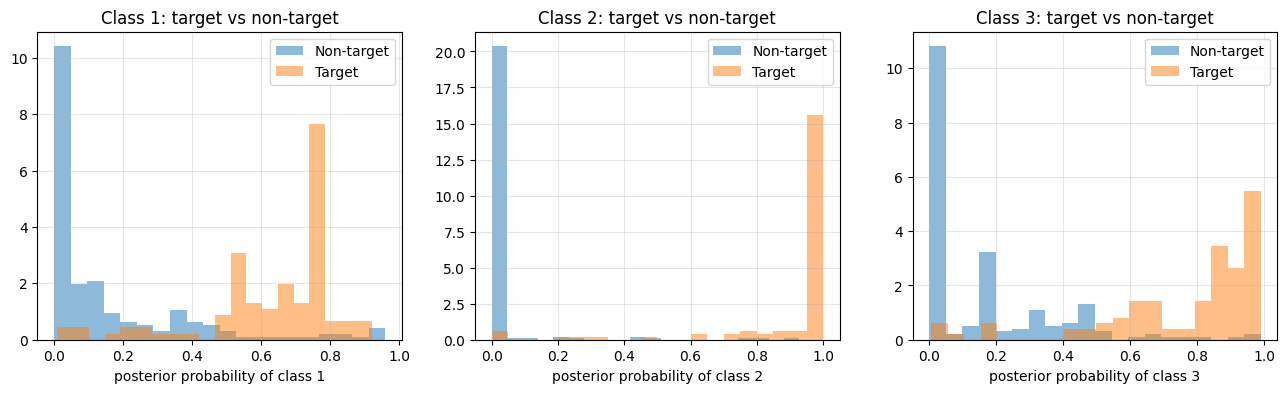

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for k in range(3):
    s = probabilities[:, k]
    axes[k].hist(s[y_test != k], bins=20, alpha=0.5, density=True, label="Non-target")
    axes[k].hist(s[y_test == k], bins=20, alpha=0.5, density=True, label="Target")
    axes[k].set_title("Class %d: target vs non-target" % (k+1))
    axes[k].set_xlabel("posterior probability of class %d" % (k+1))
    axes[k].legend()
    axes[k].grid(alpha=0.3)
plt.show()

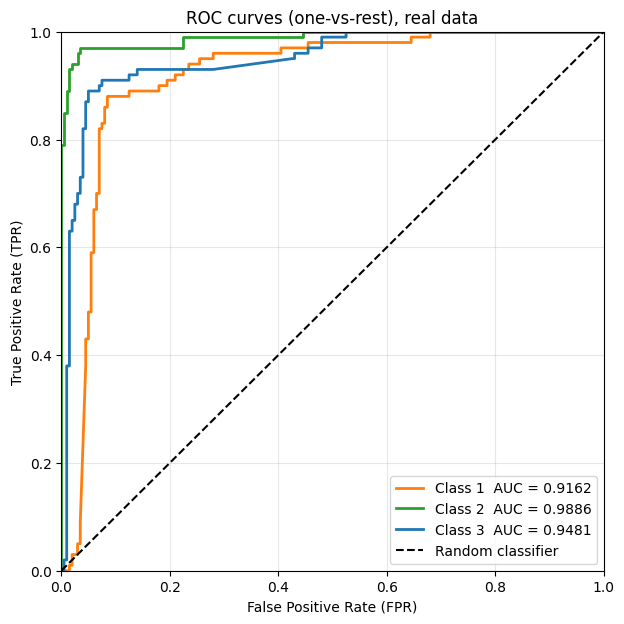

In [33]:
plt.figure(figsize=(7, 7))
auc_values = []
for k in range(3):
    is_target = (y_test == k)
    class_scores = probabilities[:, k]
    thresholds = np.concatenate(([np.inf], np.sort(np.unique(class_scores))[::-1], [-np.inf]))
    tpr = []
    fpr = []
    for t in thresholds:
        predicted = class_scores >= t
        TP = np.sum(predicted & is_target)
        FP = np.sum(predicted & ~is_target)
        FN = np.sum(~predicted & is_target)
        TN = np.sum(~predicted & ~is_target)
        tpr.append(TP / (TP + FN))
        fpr.append(FP / (FP + TN))
    tpr = np.array(tpr)
    fpr = np.array(fpr)
    auc = np.sum((fpr[1:] - fpr[:-1]) * (tpr[1:] + tpr[:-1]) / 2)      # trapezoid rule
    auc_values.append(auc)
    plt.plot(fpr, tpr, linewidth=2, color=["tab:orange", "tab:green", "tab:blue"][k], label="Class %d  AUC = %.4f" % (k+1, auc))
plt.plot([0, 1], [0, 1], "--", color="black", label="Random classifier")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC curves (one-vs-rest), real data")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()